# NUM model, 100-year global run on a GPU

`setupNUMmodel` (10 generalists, 10 diatoms, 5 copepod groups × 6 stages, 1 POM) in the MITgcm
2.8° transport matrices, started from World Ocean Atlas nitrate and run for 100 years with the
Julia/CUDA port (`scripts/spinup_global.jl`, `NUM_NPP_ALL=1`). Same model and forcing as the
30-year spin-up in `spinup_30yr.ipynb`; that notebook has the paper comparison
(Serra-Pompei et al. 2022) and the caveats about model version and forcing.

In [1]:
import json, os, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.io import loadmat
import h5py
def loadmat_any(path):
    # scipy.io.loadmat, or h5py for Matlab v7.3 files (arrays transposed back to Matlab order)
    try:
        return loadmat(path)
    except NotImplementedError:
        with h5py.File(path, "r") as h:
            return {k: np.array(h[k]).T for k in h.keys() if isinstance(h[k], h5py.Dataset)}
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="divide by zero")

ROOT = (Path("..") if Path("../reference").exists() else Path(".")).resolve()
RUN = Path(os.environ.get("NUM_CENTURY_FILE", ROOT / "reference" / "century_100yr.mat"))
with h5py.File(RUN, "r") as h:
    r = {k: np.array(h[k]) for k in h.keys() if isinstance(h[k], h5py.Dataset)}
    gnames = ["".join(chr(c) for c in col).strip() for col in np.array(h["group_names"]).T]
Umean = r["U_mean"].T; NPPbox = r["NPP_boxyear"].T            # NPPbox: boxes x years
N_year, B_year, wall = r["N_year"].ravel(), r["B_year"].T, r["wall_year"].ravel()
NPPg = r["NPP_global"].ravel(); setup_s = float(np.array(r["setup_s"]).ravel()[0])
ix, iy, iz = (r[k].ravel().astype(int) - 1 for k in ("ixBox", "iyBox", "izBox"))
vol, years = r["vol"].ravel(), int(np.array(r["years"]).ravel()[0])
GRID = os.environ.get("NUM_GRID", "MITgcm_2.8deg")
grid = loadmat_any(ROOT / "NUMmodel/TMs" / GRID / "grid.mat")
x, y, z, dz = grid["x"].ravel(), grid["y"].ravel(), grid["z"].ravel(), grid["dznom"].ravel()
nx, ny, nz = len(x), len(y), len(z)
classes = json.loads((ROOT / "reference/num_classes.json").read_text())
m = np.array([c["m"] for c in classes]); mLower = np.array([c["mLower"] for c in classes])
mDelta = np.array([c["mDelta"] for c in classes]); ctype = np.array([c["type"] for c in classes])
cgroup = np.array([c["group"] for c in classes])
nN = 3; B = Umean[:, nN:]

def to_grid(v):
    G = np.full((nx, ny, nz), np.nan); G[ix, iy, iz] = v; return G
ocean = ~np.isnan(to_grid(np.ones(len(ix)))[:, :, 0])
def integ(v, sel=None):                                # depth integral of v*dz per column
    sel = np.ones(len(ix), bool) if sel is None else sel
    G = np.zeros((nx, ny)); np.add.at(G, (ix[sel], iy[sel]), (v * dz[iz])[sel]); return np.where(ocean, G, np.nan)
def gmap(ax, field, title, norm=None, cmap="viridis", **kw):
    ax.set_facecolor("0.8")
    pc = ax.pcolormesh(x, y, field.T, norm=norm, cmap=cmap, shading="auto", **kw)
    ax.set_title(title, fontsize=10); ax.set_xticks([0, 90, 180, 270, 360]); ax.set_yticks([-60, -30, 0, 30, 60])
    return pc
print(f"{GRID}: {years} years, {Umean.shape[0]} boxes, groups: {gnames}")

MITgcm_2.8deg: 100 years, 52749 boxes, groups: ['generalist', 'diatom', 'copepod_passive', 'copepod_active', 'pom']


## 1. Timing

Wall clock per model year on the GPU, including the NPP diagnostic every transport step (an extra
biology evaluation per step, ~20% of the step cost) and the per-year copy to the host. Year 1
includes JIT compilation.

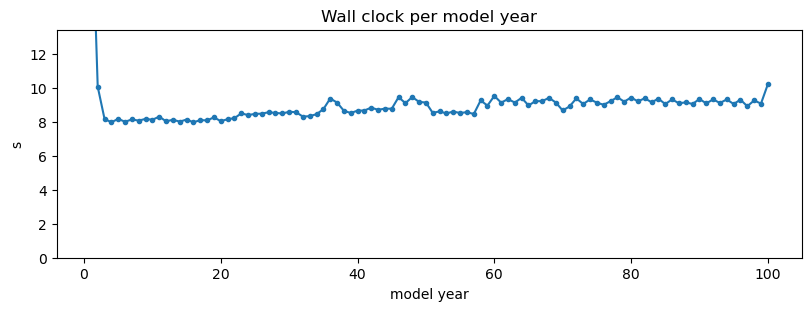

setup (load matrices, move to GPU): 51.0 s
year 1 (incl. compilation): 22.5 s; years 2-100: median 8.92 s, mean 8.84 s
total time stepping: 15.0 min for 100 model years


In [2]:
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(np.arange(1, years + 1), wall, ".-"); ax.set(xlabel="model year", ylabel="s", title="Wall clock per model year")
ax.set_ylim(0, np.percentile(wall, 99) * 1.3); plt.show()
print(f"setup (load matrices, move to GPU): {setup_s:.1f} s")
print(f"year 1 (incl. compilation): {wall[0]:.1f} s; years 2-{years}: median {np.median(wall[1:]):.2f} s, "
      f"mean {wall[1:].mean():.2f} s")
print(f"total time stepping: {wall.sum() / 60:.1f} min for {years} model years")

## 2. Time series: NPP, nitrogen inventory, group biomass

Global NPP integrated over each model year; global nitrogen (dissolved + biomass) and total
biomass per group at the end of each year.

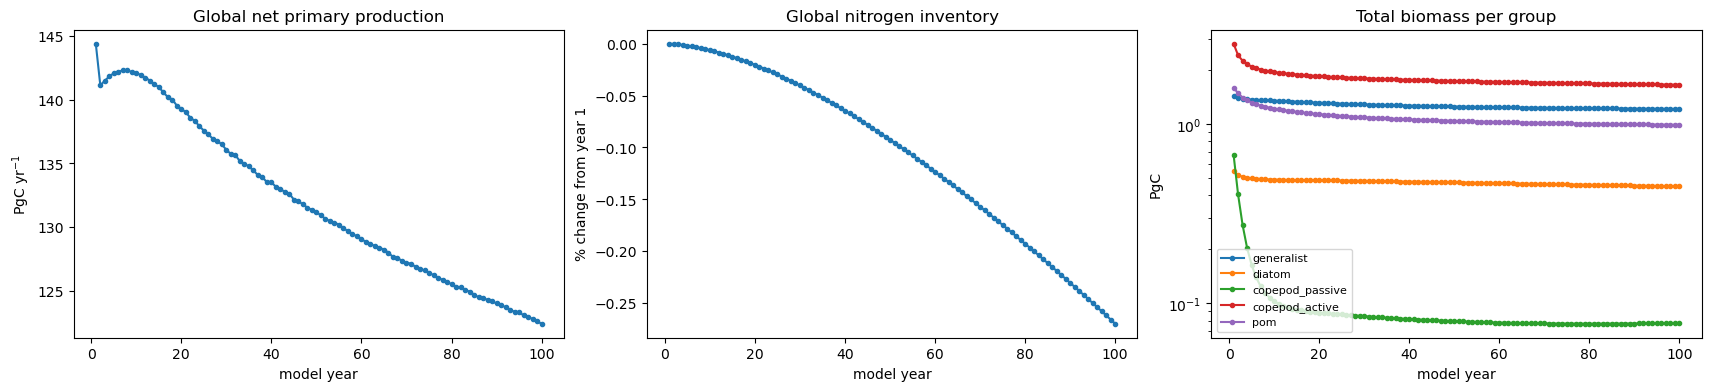

NPP year 1 144.4, year 30 136.0, year 100 122.4 PgC/yr; N inventory change over the run -0.3%


In [3]:
yrs = np.arange(1, years + 1)
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8), constrained_layout=True)
ax[0].plot(yrs, NPPg, ".-"); ax[0].set(xlabel="model year", ylabel="PgC yr$^{-1}$", title="Global net primary production")
ax[1].plot(yrs, 100 * (N_year / N_year[0] - 1), ".-"); ax[1].set(xlabel="model year", ylabel="% change from year 1", title="Global nitrogen inventory")
for k, nm in enumerate(gnames):
    ax[2].semilogy(yrs, B_year[:, k] / 1e15, ".-", label=nm)
ax[2].set(xlabel="model year", ylabel="PgC", title="Total biomass per group"); ax[2].legend(fontsize=8)
plt.show()
ymid = min(30, years // 2)
print(f"NPP year 1 {NPPg[0]:.1f}, year {ymid} {NPPg[ymid-1]:.1f}, year {years} {NPPg[-1]:.1f} PgC/yr; "
      f"N inventory change over the run {100 * (N_year[-1] / N_year[0] - 1):.1f}%")

## 3. NPP maps

Depth-integrated NPP of the final year, and its change from year 10 (year 1 for runs of 10 years
or less) to the final year.

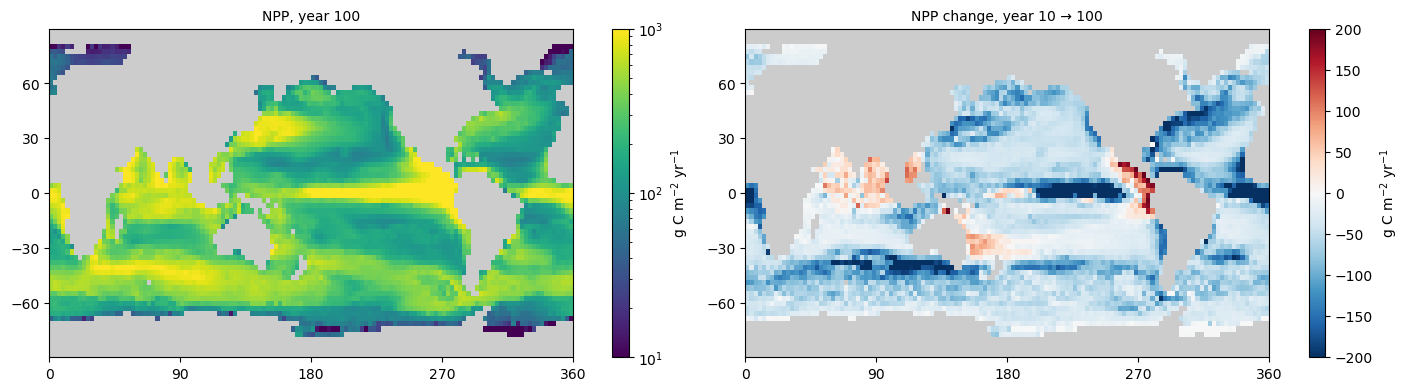

In [4]:
NPPfin = integ(NPPbox[:, -1]) / 1000                     # g C m^-2 yr^-1
yref = 10 if years > 10 else 1                           # reference year for the change map
NPP10 = integ(NPPbox[:, yref - 1]) / 1000
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8), constrained_layout=True)
fig.colorbar(gmap(axs[0], NPPfin, f"NPP, year {years}", LogNorm(10, 1000)), ax=axs[0], label="g C m$^{-2}$ yr$^{-1}$")
fig.colorbar(gmap(axs[1], NPPfin - NPP10, f"NPP change, year {yref} → {years}", None, "RdBu_r", vmin=-200, vmax=200),
             ax=axs[1], label="g C m$^{-2}$ yr$^{-1}$")
plt.show()

## 4. Size structure (final-year annual mean, 0–120 m)

Left three panels: fraction of unicellular (generalist + diatom) biomass in the pico (< 2 µm ESD),
nano (2–20 µm) and micro (> 20 µm) classes. Right: exponent λ of the normalized community size
spectrum B(m) ∝ m^λ (as in `spinup_30yr.ipynb`: upstream `calcCommunitySpectrum` construction,
least-squares fit in log–log space).

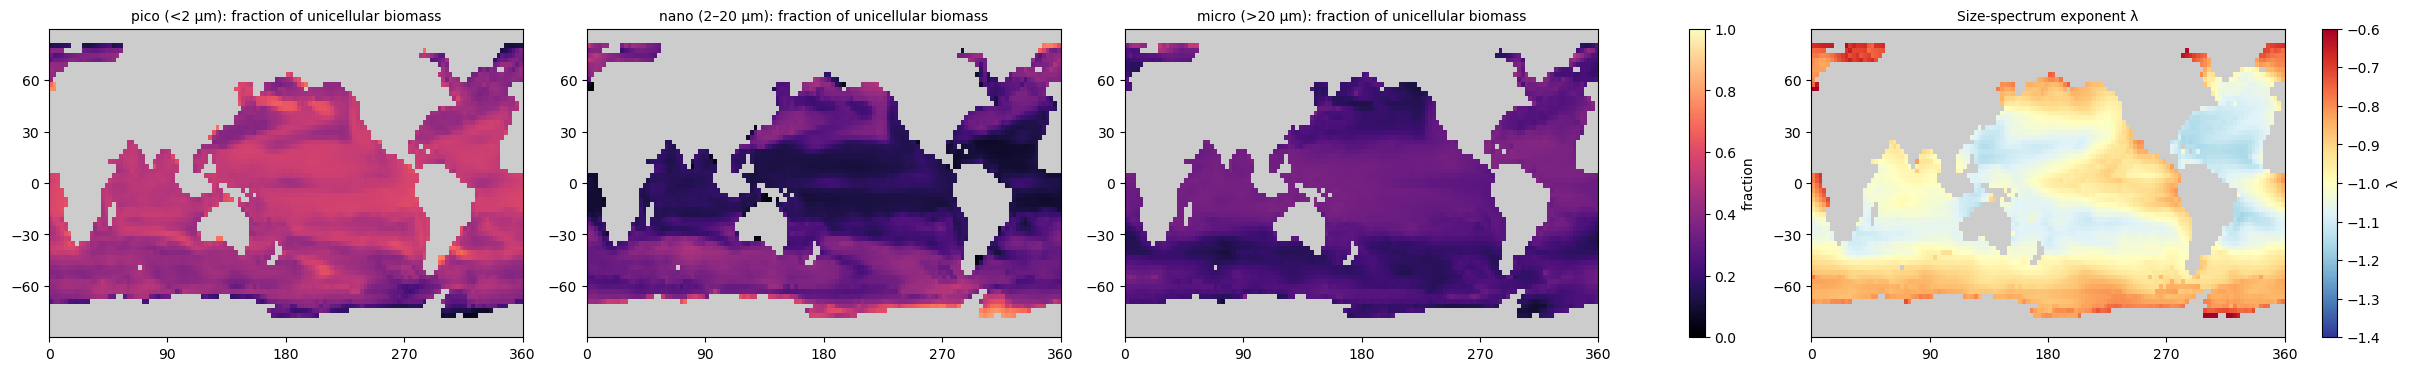

λ 5-95%: -1.12 to -0.80


In [5]:
up = iz < 2
prot = np.isin(ctype, ["Generalists", "Diatoms"])
esd = 1e4 * 1.5 * (m * 1e-6) ** (1 / 3)
cls = {"pico (<2 µm)": prot & (esd <= 2), "nano (2–20 µm)": prot & (esd > 2) & (esd <= 20), "micro (>20 µm)": prot & (esd > 20)}
parts = np.stack([integ(B[:, s].sum(1), up) for s in cls.values()], axis=-1)
frac = parts / parts.sum(-1, keepdims=True)

Bup = np.zeros((nx, ny, B.shape[1])); np.add.at(Bup, (ix[up], iy[up]), B[up] * dz[iz[up], None]); Bup /= dz[:2].sum()
mc = np.logspace(np.log10(m.min()), np.log10(m[ctype != "POM"].max()), 100)
def community_spectrum(Bcols):
    Bc = np.where(Bcols > 0, Bcols, 1e-100)
    BSh = np.zeros(Bc.shape[:-1] + (len(mc),))
    for gi in np.unique(cgroup):
        sel = cgroup == gi
        if ctype[sel][0] == "POM":
            continue
        logk = np.log(Bc[..., sel] / np.log((mLower[sel] + mDelta[sel]) / mLower[sel]))
        lm = np.log(m[sel]); inside = (np.log(mc) >= lm[0]) & (np.log(mc) <= lm[-1])
        BSh[..., inside] += np.exp(np.apply_along_axis(lambda v: np.interp(np.log(mc[inside]), lm, v), -1, logk))
    dff = np.diff(np.log(mc)); mU = np.exp(np.log(mc) + 0.5 * np.append(dff, dff[-1])); mL = np.exp(np.log(mc) - 0.5 * np.insert(dff, 0, dff[0]))
    return BSh / (mU - mL) * (mc[1] / mc[0])
def fit_exponent(sp):
    ok = sp > 1e-12 * sp.max()
    return np.polyfit(np.log(mc[ok]), np.log(sp[ok]), 1)[0] if ok.sum() > 10 else np.nan
lam = np.full((nx, ny), np.nan); lam[ocean] = [fit_exponent(sp) for sp in community_spectrum(Bup[ocean])]

fig, axs = plt.subplots(1, 4, figsize=(24, 3.6), constrained_layout=True)
for ax, k, f in zip(axs[:3], cls, np.moveaxis(frac, -1, 0)):
    pc = gmap(ax, f, f"{k}: fraction of unicellular biomass", None, "magma", vmin=0, vmax=1)
fig.colorbar(pc, ax=axs[:3], label="fraction")
fig.colorbar(gmap(axs[3], lam, "Size-spectrum exponent λ", None, "RdYlBu_r", vmin=-1.4, vmax=-0.6), ax=axs[3], label="λ")
plt.show()
print(f"λ 5-95%: {np.nanpercentile(lam, 5):.2f} to {np.nanpercentile(lam, 95):.2f}")

## 5. Global size spectrum

Area-weighted mean 0–120 m community spectrum of the final year, split into unicellulars and
copepods.

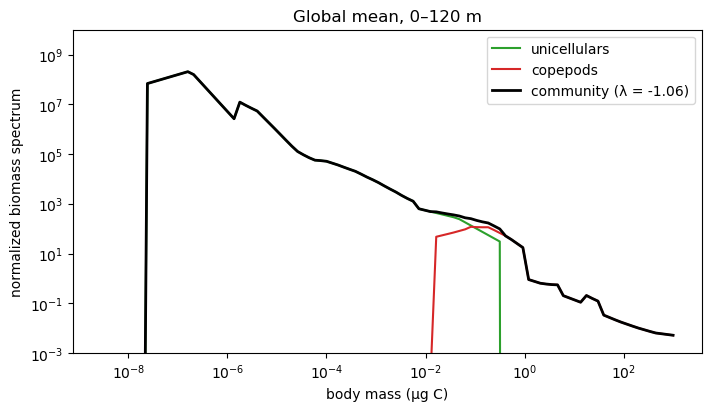

In [6]:
area = np.zeros((nx, ny)); s0 = iz == 0; area[ix[s0], iy[s0]] = vol[s0] / dz[0]
Bglob = (Bup[ocean] * area[ocean][:, None]).sum(0) / area[ocean].sum()
cope = np.isin(ctype, ["Passive copepods", "Active copepods"])
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for label, sel, col in (("unicellulars", prot, "tab:green"), ("copepods", cope, "tab:red")):
    ax.loglog(mc, community_spectrum(np.where(sel, Bglob, 0)[None, :])[0], color=col, label=label)
tot = community_spectrum(Bglob[None, :])[0]
ax.loglog(mc, tot, "k", lw=2, label=f"community (λ = {fit_exponent(tot):.2f})")
ax.set(xlabel="body mass (µg C)", ylabel="normalized biomass spectrum", ylim=(1e-3, 1e10), title="Global mean, 0–120 m")
ax.legend(); plt.show()